# Tracked-Coordinate-Intersection-Only Zonotope CG Enclosure for the Updated Plate

This notebook adapts the v6 intersect-first formulation to the 21,570-coordinate `system_updated_plate` problem. It preserves the plate data conventions, symmetric Jacobi scaling, fixed 2,200-step CG recurrence, and robust independent-direction selection used by the existing plate notebooks.

For each configured box, the experiment takes snapshots at

$$m=150,300,\ldots,2100,2200,$$

and computes coordinate extrema for 80 evenly sampled coordinates using **tracked-coordinate intersection only**. This is a relaxation of the full $\mathcal Z_m\cap B_0$ intersection: box constraints are imposed only on those same 80 tracked output coordinates, and no untracked output coordinate is constrained or checked.

The dense matrix $M=\Pi_mD_0$ is never formed. The 80 required full rows are evaluated through the low-rank representation

$$
\Pi_m=I-P_mG_m^{-1}P_m^T A.
$$

At each snapshot, the 80 upper and 80 lower tracked-coordinate inequalities form one fixed 160-row LP constraint matrix. Every one of the 160 min/max objectives uses this same feasible region and the full latent vector $z\in[-1,1]^n$, so every component of $z$ still influences every tracked-coordinate bound. No preliminary feasibility LP, cut refinement, full-box certification, or untracked-coordinate violation scan is performed. No accumulated floating-point CG hyperplane equalities are imposed.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve
from scipy.optimize import linprog
from scipy.sparse import diags, load_npz

from system_updated_plate.cg_projection_enclosure import (
    fixed_iteration_cg_with_directions,
    select_independent_directions,
)


data_dir = Path("system_updated_plate")
A_original = load_npz(data_dir / "A.npz").tocsr()
b_original = np.loadtxt(data_dir / "b.dat", dtype=float)
x_star = np.loadtxt(data_dir / "soln_x.dat", dtype=float)

boxes = {
    "box_1": np.loadtxt(data_dir / "box_1.dat", dtype=float),
    # "box_2": np.loadtxt(data_dir / "box_2.dat", dtype=float),
}

n = len(b_original)
if A_original.shape != (n, n):
    raise ValueError(f"Expected A to have shape {(n, n)}, got {A_original.shape}.")
if x_star.shape != (n,):
    raise ValueError(f"Expected x_star to have shape {(n,)}, got {x_star.shape}.")
for box_name, box in boxes.items():
    if box.shape != (n, 2):
        raise ValueError(f"{box_name} should have shape {(n, 2)}, got {box.shape}.")
    if np.any(box[:, 0] > box[:, 1]):
        raise ValueError(f"{box_name} has lower bounds above upper bounds.")
    if not np.all((box[:, 0] <= x_star) & (x_star <= box[:, 1])):
        raise ValueError(f"{box_name} does not contain x_star.")

print(f"system dimension: {n}")
print(f"matrix nonzeros: {A_original.nnz}")
print(f"boxes: {', '.join(boxes)}")
print(f"stored solution residual: {np.linalg.norm(b_original - A_original @ x_star):.6e}")

system dimension: 21570
matrix nonzeros: 659988
boxes: box_1
stored solution residual: 4.866280e-11


## Jacobi scaling and experiment controls

The LP and projector calculations use $y=\mathrm{scale}\,x$, with `scale = sqrt(diag(A_original))`. Reported enclosures are transformed back to the original coordinates.

The LP imposes original-box constraints only on the 80 tracked output coordinates. The resulting bounds are therefore for the tracked-coordinate-intersection-only relaxation, not the full $\mathcal Z_m\cap B_0$ intersection.

In [2]:
diagonal = A_original.diagonal()
if np.any(diagonal <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A = (diags(inverse_scale) @ A_original @ diags(inverse_scale)).tocsr()
b = inverse_scale * b_original
x_star_scaled = scale * x_star

max_iterations = 2200
snapshot_period = 150
snapshot_iterations = np.arange(snapshot_period, max_iterations + 1, snapshot_period)
if snapshot_iterations[-1] != max_iterations:
    snapshot_iterations = np.append(snapshot_iterations, max_iterations)

max_tracked_coordinates = 80
tracked_indices = np.unique(
    np.linspace(0, n - 1, min(n, max_tracked_coordinates)).round().astype(int)
)

projection_qr_tolerance = 1e-10
projection_max_gram_condition = 1e12
sanity_atol = 1e-8
sanity_rtol = 1e-10
intersection_method = "tracked-coordinate intersection only"

print(f"CG iterations per box: {max_iterations}")
print(f"snapshots: {snapshot_iterations.tolist()}")
print(f"tracked coordinate objectives: {len(tracked_indices)}")
print(f"fixed tracked-output inequalities per snapshot: {2 * len(tracked_indices)}")
print(f"method: {intersection_method} (relaxation of full Z_m intersection B_0)")

CG iterations per box: 2200
snapshots: [150, 300, 450, 600, 750, 900, 1050, 1200, 1350, 1500, 1650, 1800, 1950, 2100, 2200]
tracked coordinate objectives: 80
fixed tracked-output inequalities per snapshot: 160
method: tracked-coordinate intersection only (relaxation of full Z_m intersection B_0)


## Implicit zonotope and fixed tracked-coordinate LP

For a selected basis, `ImplicitZonotope` computes $\widehat x_m$ and the 80 requested full rows of $M=\Pi_mD_0$ without forming all of $M$.

For an upper tracked-coordinate constraint at coordinate $j$,

$$M_{j,:}z\le u^0_j-\widehat x_{m,j},$$

and for a lower tracked-coordinate constraint,

$$-M_{j,:}z\le \widehat x_{m,j}-\ell^0_j.$$

Here $j$ ranges only over `tracked_indices`. The LP variables remain the entire $z\in[-1,1]^n$, and the fixed 160-row `A_ub`, `b_ub`, and variable bounds are reused for all 160 min/max solves in the snapshot. Untracked output coordinates are neither constrained nor checked.

In [3]:
class ImplicitZonotope:
    """Low-rank representation of x_hat + Pi D0 z."""

    def __init__(self, A, b, lower, upper, selection):
        self.A = A
        self.b = b
        self.lower = np.asarray(lower, dtype=float)
        self.upper = np.asarray(upper, dtype=float)
        self.center = 0.5 * (self.lower + self.upper)
        self.d0 = 0.5 * (self.upper - self.lower)
        self.basis = selection["basis"]
        self.applied_basis = selection["applied_basis"]
        self.gram = selection["gram"]
        self.n = len(b)

        coefficients = solve(
            self.gram,
            self.basis.T @ (b - A @ self.center),
            assume_a="sym",
            check_finite=False,
        )
        self.x_hat = self.center + self.basis @ coefficients

    def rows(self, indices):
        """Return requested full rows of M = Pi D0 in one batch."""
        indices = np.asarray(indices, dtype=int)
        left = solve(
            self.gram,
            self.basis[indices, :].T,
            assume_a="sym",
            check_finite=False,
        )
        rows = -(self.applied_basis @ left).T
        rows *= self.d0[None, :]
        rows[np.arange(len(indices)), indices] += self.d0[indices]
        return rows


def solve_tracked_intersection_lp(c, A_ub, b_ub, bounds, context):
    """Solve one objective over the fixed tracked-coordinate relaxation."""
    result = linprog(
        c,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(
            f"Tracked-coordinate-intersection LP failed for {context}: "
            f"status={result.status}, message={result.message!r}"
        )
    return result

## One snapshot

The 80 full objective rows and the fixed 160-inequality matrix are constructed once per snapshot. The optimization timer starts immediately before the first tracked-coordinate LP, includes all 160 min/max solves over that same matrix, and stops immediately after the last bound is recovered. There is no preliminary feasibility solve. CG, basis selection, Gram construction, creation of $\widehat x_m$, and construction of the fixed LP matrix are outside the timer.

In [4]:
def intersect_first_tracked_snapshot(
    A,
    b,
    lower,
    upper,
    selection,
    tracked_indices,
    snapshot_m,
    box_name,
):
    zonotope = ImplicitZonotope(A, b, lower, upper, selection)
    tracked_indices = np.asarray(tracked_indices, dtype=int)
    tracked_rows = zonotope.rows(tracked_indices)
    tracked_x_hat = zonotope.x_hat[tracked_indices]

    # These are the only output-space box constraints. Every row still has n
    # coefficients, so every latent component of z influences every objective.
    A_ub = np.concatenate((tracked_rows, -tracked_rows), axis=0)
    b_ub = np.concatenate(
        (upper[tracked_indices] - tracked_x_hat, tracked_x_hat - lower[tracked_indices])
    )
    bounds = (-1.0, 1.0)
    constraint_count = A_ub.shape[0]
    expected_constraint_count = 2 * len(tracked_indices)
    if A_ub.shape != (expected_constraint_count, len(b)):
        raise RuntimeError(
            f"Expected fixed LP matrix shape {(expected_constraint_count, len(b))}, "
            f"got {A_ub.shape}."
        )

    tracked_lower = np.empty(len(tracked_indices))
    tracked_upper = np.empty(len(tracked_indices))
    min_status = np.empty(len(tracked_indices), dtype=int)
    max_status = np.empty(len(tracked_indices), dtype=int)

    optimization_start = perf_counter()
    for local, coordinate in enumerate(tracked_indices):
        min_result = solve_tracked_intersection_lp(
            c=tracked_rows[local],
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            context={
                "box": box_name,
                "m": int(snapshot_m),
                "stage": "minimum",
                "coordinate": int(coordinate),
            },
        )
        max_result = solve_tracked_intersection_lp(
            c=-tracked_rows[local],
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            context={
                "box": box_name,
                "m": int(snapshot_m),
                "stage": "maximum",
                "coordinate": int(coordinate),
            },
        )

        tracked_lower[local] = zonotope.x_hat[coordinate] + min_result.fun
        tracked_upper[local] = zonotope.x_hat[coordinate] - max_result.fun
        min_status[local] = min_result.status
        max_status[local] = max_result.status
        if (local + 1) % 10 == 0 or local + 1 == len(tracked_indices):
            print(
                f"  {box_name} m={snapshot_m}: extrema "
                f"{local + 1}/{len(tracked_indices)}, "
                f"fixed tracked constraints={constraint_count}",
                flush=True,
            )

    optimization_time = perf_counter() - optimization_start
    return {
        "l_m_scaled": tracked_lower,
        "u_m_scaled": tracked_upper,
        "optimization_time": float(optimization_time),
        "min_status": min_status,
        "max_status": max_status,
        "intersection_method": intersection_method,
        "constraint_count": int(constraint_count),
    }

## Run the configured boxes through 2,200 CG iterations

In [5]:
plate_results = {}
checkpoint_dir = Path("system_updated_plate_v6_checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

for box_name, box in boxes.items():
    print(f"\n=== {box_name} ===", flush=True)
    l0 = scale * box[:, 0]
    u0 = scale * box[:, 1]
    c0 = 0.5 * (l0 + u0)

    # Run CG once per box and reuse every prefix. CG time is not LP time.
    cg_run = fixed_iteration_cg_with_directions(
        A=A,
        b=b,
        x0=c0,
        iterations=max_iterations,
    )
    box_snapshots = []
    tracked_initial_width = box[tracked_indices, 1] - box[tracked_indices, 0]

    for m in snapshot_iterations:
        selection = select_independent_directions(
            directions=cg_run["directions"][:, :m],
            applied_directions=cg_run["applied_directions"][:, :m],
            qr_tolerance=projection_qr_tolerance,
            max_gram_condition=projection_max_gram_condition,
        )

        snapshot = intersect_first_tracked_snapshot(
            A=A,
            b=b,
            lower=l0,
            upper=u0,
            selection=selection,
            tracked_indices=tracked_indices,
            snapshot_m=int(m),
            box_name=box_name,
        )

        l_m = snapshot["l_m_scaled"] / scale[tracked_indices]
        u_m = snapshot["u_m_scaled"] / scale[tracked_indices]
        widths = u_m - l_m
        with np.errstate(divide="ignore", invalid="ignore"):
            contraction = 100.0 * (1.0 - widths / tracked_initial_width)

        reference_scale = max(
            1.0,
            float(np.max(np.abs(l_m))),
            float(np.max(np.abs(u_m))),
            float(np.max(np.abs(x_star[tracked_indices]))),
        )
        sanity_tolerance = sanity_atol + sanity_rtol * reference_scale
        order_violation = max(0.0, float(np.max(l_m - u_m)))
        containment_violation = max(
            0.0,
            float(np.max(l_m - x_star[tracked_indices])),
            float(np.max(x_star[tracked_indices] - u_m)),
        )

        snapshot.update(
            {
                "m": int(m),
                "rank": int(selection["retained_rank"]),
                "qr_rank": int(selection["qr_rank"]),
                "gram_condition": float(selection["gram_condition"]),
                "l_m": l_m,
                "u_m": u_m,
                "width_min": float(np.min(widths)),
                "width_mean": float(np.mean(widths)),
                "width_max": float(np.max(widths)),
                "contraction_min_pct": float(np.nanmin(contraction)),
                "contraction_mean_pct": float(np.nanmean(contraction)),
                "contraction_median_pct": float(np.nanmedian(contraction)),
                "contraction_max_pct": float(np.nanmax(contraction)),
                "max_order_violation": float(order_violation),
                "max_x_star_violation": float(containment_violation),
                "order_ok": bool(order_violation <= sanity_tolerance),
                "contains_x_star": bool(containment_violation <= sanity_tolerance),
                "sanity_tolerance": float(sanity_tolerance),
            }
        )
        box_snapshots.append(snapshot)

        checkpoint_path = checkpoint_dir / f"{box_name}_m_{int(m):04d}.npz"
        np.savez_compressed(
            checkpoint_path,
            box_name=np.array(box_name),
            m=np.array(int(m)),
            tracked_indices=tracked_indices,
            rank=np.array(snapshot["rank"]),
            qr_rank=np.array(snapshot["qr_rank"]),
            gram_condition=np.array(snapshot["gram_condition"]),
            l_m=snapshot["l_m"],
            u_m=snapshot["u_m"],
            optimization_time=np.array(snapshot["optimization_time"]),
            intersection_method=np.array(snapshot["intersection_method"]),
            constraint_count=np.array(snapshot["constraint_count"]),
            min_status=snapshot["min_status"],
            max_status=snapshot["max_status"],
            max_order_violation=np.array(snapshot["max_order_violation"]),
            max_x_star_violation=np.array(snapshot["max_x_star_violation"]),
        )

        print(
            f"Snapshot {box_name} m={m}: rank(P)={selection['retained_rank']}, "
            f"optimization time={snapshot['optimization_time']:.2f} s, "
            f"{snapshot['constraint_count']} fixed tracked constraints "
            f"({snapshot['intersection_method']})",
            flush=True,
        )
        print(
            f"  tracked width min/mean/max={widths.min():.6e} / "
            f"{widths.mean():.6e} / {widths.max():.6e}; "
            f"contraction min/mean/median/max={np.nanmin(contraction):.2f}% / "
            f"{np.nanmean(contraction):.2f}% / {np.nanmedian(contraction):.2f}% / "
            f"{np.nanmax(contraction):.2f}%",
            flush=True,
        )
        print(f"  checkpoint saved: {checkpoint_path}", flush=True)
        if not snapshot["order_ok"]:
            print(
                f"  SANITY FAILURE: interval order max violation="
                f"{order_violation:.6e}",
                flush=True,
            )
        if not snapshot["contains_x_star"]:
            print(
                f"  SANITY FAILURE: x_star max violation="
                f"{containment_violation:.6e}",
                flush=True,
            )

    plate_results[box_name] = {
        "snapshots": box_snapshots,
        "residual_norms": cg_run["residual_norms"].copy(),
    }
    del cg_run

print("\nCompleted all requested box/snapshot combinations.")


=== box_1 ===
  box_1 m=150: extrema 10/80, fixed tracked constraints=160
  box_1 m=150: extrema 20/80, fixed tracked constraints=160
  box_1 m=150: extrema 30/80, fixed tracked constraints=160
  box_1 m=150: extrema 40/80, fixed tracked constraints=160
  box_1 m=150: extrema 50/80, fixed tracked constraints=160
  box_1 m=150: extrema 60/80, fixed tracked constraints=160
  box_1 m=150: extrema 70/80, fixed tracked constraints=160
  box_1 m=150: extrema 80/80, fixed tracked constraints=160
Snapshot box_1 m=150: rank(P)=148, optimization time=836.38 s, 160 fixed tracked constraints (tracked-coordinate intersection only)
  tracked width min/mean/max=1.819373e-04 / 6.042725e-01 / 2.799708e+00; contraction min/mean/median/max=-0.00% / -0.00% / -0.00% / 0.00%
  checkpoint saved: system_updated_plate_v6_checkpoints/box_1_m_0150.npz
  box_1 m=300: extrema 10/80, fixed tracked constraints=160
  box_1 m=300: extrema 20/80, fixed tracked constraints=160
  box_1 m=300: extrema 30/80, fixed tracke

## Expose and save compact arrays

`plate_results` contains the tracked-coordinate-intersection-only bounds and LP statuses. The compact archive stores the method label, fixed constraint counts, tracked bounds, ranks, optimization times, contraction, and inexpensive tracked-coordinate sanity diagnostics.

In [6]:
box_names = np.array(list(plate_results))

rank_history = np.array([
    [snapshot["rank"] for snapshot in plate_results[name]["snapshots"]]
    for name in box_names
])
optimization_times = np.array([
    [snapshot["optimization_time"] for snapshot in plate_results[name]["snapshots"]]
    for name in box_names
])
l_history = np.array([
    [snapshot["l_m"] for snapshot in plate_results[name]["snapshots"]]
    for name in box_names
])
u_history = np.array([
    [snapshot["u_m"] for snapshot in plate_results[name]["snapshots"]]
    for name in box_names
])
constraint_counts = np.array([
    [snapshot["constraint_count"] for snapshot in plate_results[name]["snapshots"]]
    for name in box_names
])
all_lp_statuses = np.array([
    [
        np.concatenate((snapshot["min_status"], snapshot["max_status"]))
        for snapshot in plate_results[name]["snapshots"]
    ]
    for name in box_names
])
order_violations = np.array([
    [snapshot["max_order_violation"] for snapshot in plate_results[name]["snapshots"]]
    for name in box_names
])
x_star_violations = np.array([
    [snapshot["max_x_star_violation"] for snapshot in plate_results[name]["snapshots"]]
    for name in box_names
])

tracked_initial_widths = np.array([
    boxes[name][tracked_indices, 1] - boxes[name][tracked_indices, 0]
    for name in box_names
])
with np.errstate(divide="ignore", invalid="ignore"):
    contraction_history = 100.0 * (
        1.0
        - (u_history - l_history) / tracked_initial_widths[:, None, :]
    )

results_path = Path("system_updated_plate_solver_v6_snapshot_results.npz")
np.savez_compressed(
    results_path,
    box_names=box_names,
    tracked_indices=tracked_indices,
    intersection_method=np.array(intersection_method),
    m=snapshot_iterations,
    rank=rank_history,
    l_m=l_history,
    u_m=u_history,
    optimization_time=optimization_times,
    constraint_count=constraint_counts,
    lp_status=all_lp_statuses,
    contraction_pct=contraction_history,
    max_order_violation=order_violations,
    max_x_star_violation=x_star_violations,
)

print(f"saved snapshot arrays to: {results_path}")
print(f"method: {intersection_method}")
print(f"all tracked-coordinate LP statuses successful: {np.all(all_lp_statuses == 0)}")
print(f"all snapshots used exactly 160 constraints: {np.all(constraint_counts == 160)}")
print(f"all interval-order checks passed: {np.all(order_violations == 0.0)}")
print(f"x_star is in every tracked enclosure: {np.all(x_star_violations == 0.0)}")

saved snapshot arrays to: system_updated_plate_solver_v6_snapshot_results.npz
method: tracked-coordinate intersection only
all tracked-coordinate LP statuses successful: True
all snapshots used exactly 160 constraints: True
all interval-order checks passed: True
x_star is in every tracked enclosure: True


## Optimization cost and selected rank

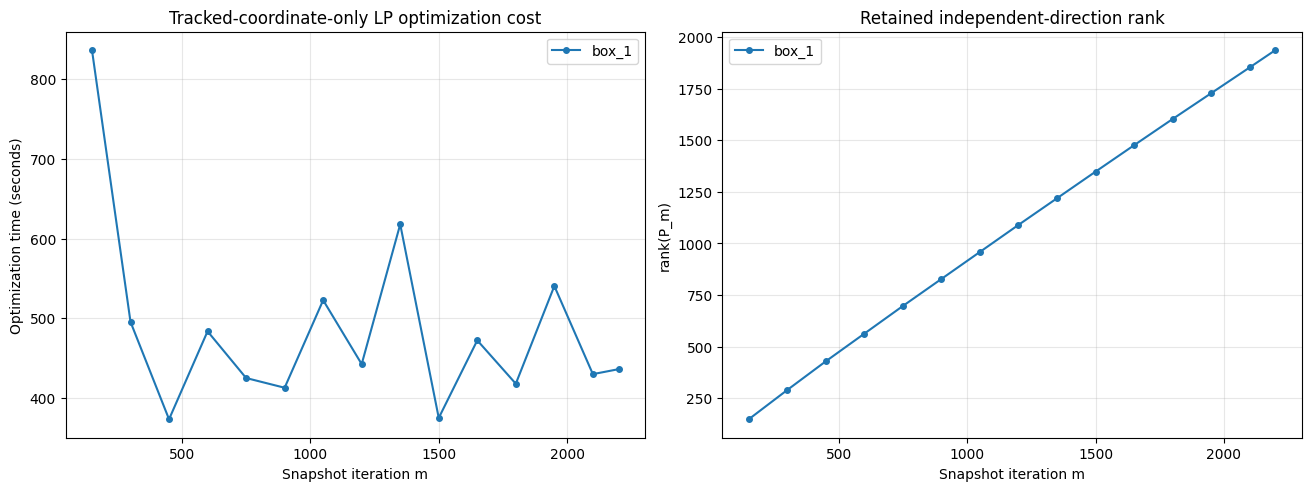

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for box_index, box_name in enumerate(box_names):
    axes[0].plot(
        snapshot_iterations,
        optimization_times[box_index],
        marker="o",
        markersize=4,
        label=box_name,
    )
    axes[1].plot(
        snapshot_iterations,
        rank_history[box_index],
        marker="o",
        markersize=4,
        label=box_name,
    )

axes[0].set_title("Tracked-coordinate-only LP optimization cost")
axes[0].set_xlabel("Snapshot iteration m")
axes[0].set_ylabel("Optimization time (seconds)")
axes[1].set_title("Retained independent-direction rank")
axes[1].set_xlabel("Snapshot iteration m")
axes[1].set_ylabel("rank(P_m)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

## Tracked-coordinate contraction and final bounds

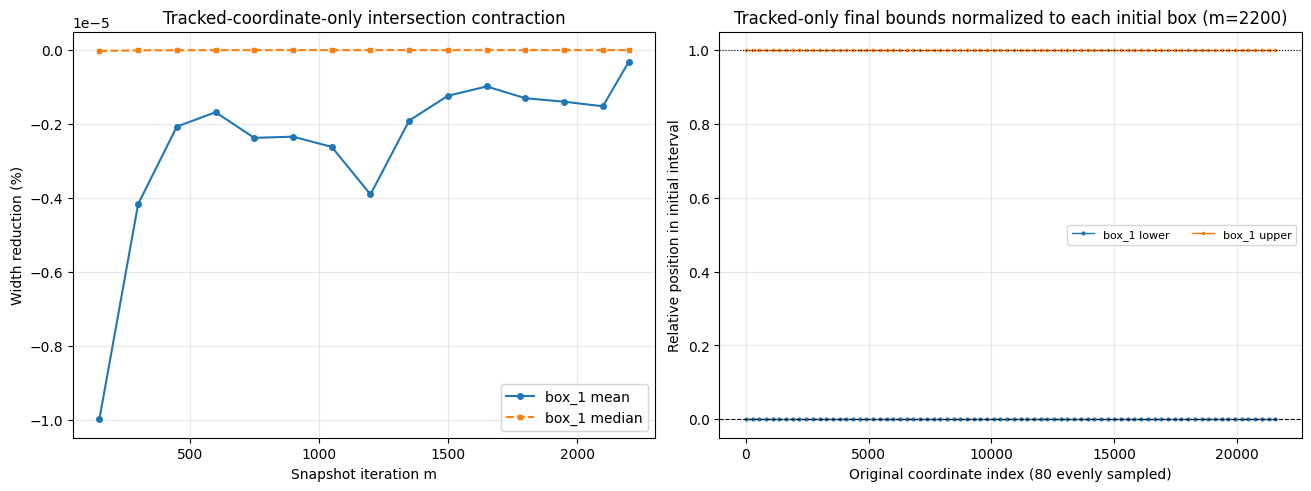

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for box_index, box_name in enumerate(box_names):
    axes[0].plot(
        snapshot_iterations,
        np.nanmean(contraction_history[box_index], axis=1),
        marker="o",
        markersize=4,
        label=f"{box_name} mean",
    )
    axes[0].plot(
        snapshot_iterations,
        np.nanmedian(contraction_history[box_index], axis=1),
        marker="s",
        markersize=3,
        linestyle="--",
        label=f"{box_name} median",
    )

axes[0].set_title("Tracked-coordinate-only intersection contraction")
axes[0].set_xlabel("Snapshot iteration m")
axes[0].set_ylabel("Width reduction (%)")
axes[0].grid(alpha=0.3)
axes[0].legend()

for box_index, box_name in enumerate(box_names):
    initial_lower = boxes[box_name][tracked_indices, 0]
    initial_width = tracked_initial_widths[box_index]
    normalized_lower = (l_history[box_index, -1] - initial_lower) / initial_width
    normalized_upper = (u_history[box_index, -1] - initial_lower) / initial_width
    axes[1].plot(
        tracked_indices,
        normalized_lower,
        marker="o",
        markersize=2,
        linewidth=1,
        label=f"{box_name} lower",
    )
    axes[1].plot(
        tracked_indices,
        normalized_upper,
        marker="s",
        markersize=2,
        linewidth=1,
        label=f"{box_name} upper",
    )

axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].axhline(1.0, color="black", linewidth=0.8, linestyle=":")
axes[1].set_title(
    f"Tracked-only final bounds normalized to each initial box "
    f"(m={snapshot_iterations[-1]})"
)
axes[1].set_xlabel("Original coordinate index (80 evenly sampled)")
axes[1].set_ylabel("Relative position in initial interval")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8, ncol=2)

plt.show()